In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

# The Boundary Integral Equation (BIE) approach
Reference: Per-Gunnar Martinsson, "Fast direct solvers for elliptic PDEs", SIAM 2019 https://epubs.siam.org/doi/book/10.1137/1.9781611976045
* Chapter 2: a general overview theory for the boundary integral equation methods
* Chapter 10: theory for the boundary integral equation methods
* Chapter 12: numerics for the BIE methods

We consider Laplace's equation in a 2D compact simply-connected domain $\Omega$ with a smooth boundary $\Gamma$ and Dirichlet boundary data on it:
$$
\begin{cases}
\Delta u = 0, & x\in \Omega\\ u = f(x),& x\in\Gamma.
\end{cases}
$$
We define the *double-layer kernel* function as
$$
d(x,y) = n(y)\cdot\nabla_y\phi(x-y),
$$
where $x\in\bar{\Omega}$, $y\in\Gamma$,  $n(y)$ is the outer unit normal to $\Gamma$,
$$
\phi(x-y) = -\frac{1}{2\pi}\log\|x-y\|
$$
is the fundamental solution to Laplace's operator in 2D:
$$
-\Delta\phi(x) = \delta(x),\quad\text{the Dirac $\delta$-function}.
$$
Therefore,
$$
d(x,y) = \frac{n(y)\cdot(x-y)}{2\pi\|x-y\|^2}.
$$
The function $d(x,y)$ is a smooth function of $y$ for any fixed $x\in\Gamma$, provided that $\Gamma$ is smooth. However, it has a singularity as $x'\rightarrow x$, where $x\in\Gamma$ is fixed, and $x'\in\Omega$. 

The fact that $d(x,y)$ is smooth for each fixed $x$, allows us to compute the contour integral 
$$
[D\sigma](x): = \int_{\Gamma} d(x,y)\sigma(y) ds(y)
$$
for each fixed $x$.
We look for the solution $u$ of the form $u(x) = [D\sigma](x)$, where $\sigma$ is to be found. The discontinuity in $x$ results in the following equation that allows us to find $\sigma$ from the boundary condition:
$$
-\frac{1}{2}\sigma(x) + [D\sigma](x) = f(x).
$$

# Test problem 1
We start with a problem with a known exact solution, so that we can check the accuracy of the numerical solution. The region $\Omega$ is a unit circle $\{x\mid \|x\| < 1\}$. The boundary condition is $f(x) = 1 + \cos(3\phi(x))$, where $\phi(x)$ is the polar angle of $x$. The problem rewritten in the polar coordinates is 
$$
\begin{cases}
u_{rr} +\frac{1}{r}u_r + \frac{1}{r^2}u_{\phi\phi} = 0,& r < 1\\
u = 1 + \cos(3\phi),& r = 1.
\end{cases}
$$
The exact solution can be found unsing separation of variables:
$$
u(r,\theta) = 1 + r^3\cos(3\phi).
$$

In [2]:
# Define the exact solution function and triangulate the domain
def exact_sol1(x):
    r = np.linalg.norm(x)
    phi = np.arctan2(x[1],x[0]) # template: np.arctan2(y,x)
    return 1 + r**3*np.cos(3*phi)

# define the boundary function
def bdry_func(phi):
    return 1 + np.cos(3*phi)

import pygmsh

def mesh_unit_circle(h):
    with pygmsh.occ.Geometry() as geom:   # <-- change is here
        geom.add_disk([0.0, 0.0, 0.0], 1.0)
        # Set global mesh size
        h = 0.1
        geom.characteristic_length_min = h
        geom.characteristic_length_max = h
        mesh = geom.generate_mesh()

    pts = mesh.points[:, :2]
    tri = mesh.cells_dict["triangle"]
    return pts, tri

Text(0.5, 1.0, 'Triangulation of Unit Circle')

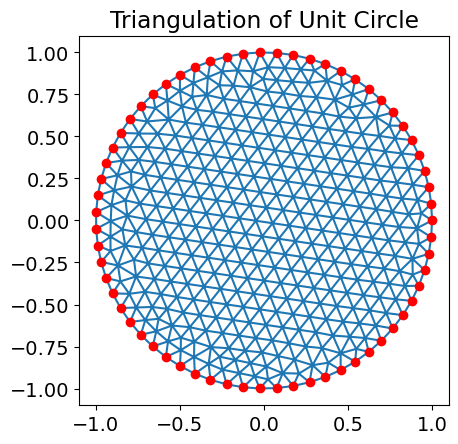

In [3]:
# plot triangulation
h_mesh = 0.1
pts,tri = mesh_unit_circle(h_mesh)
Npts = np.size(pts,axis = 0)

# find interior mesh points
bdry_label = np.zeros((Npts,))
for j in range(Npts):
    x = pts[j,:]
    if np.abs(np.linalg.norm(x) - 1) < 1e-10:
        bdry_label[j] = 1
Interior = np.argwhere(bdry_label == 0).ravel() 
Bdry = np.argwhere(bdry_label == 1).ravel()

plt.figure()
plt.triplot(pts[:,0], pts[:,1], tri)
plt.scatter(pts[Bdry,0],pts[Bdry,1],c = 'red')
plt.gca().set_aspect('equal')
plt.title("Triangulation of Unit Circle")


Text(0.5, 1.0, 'The exact solution')

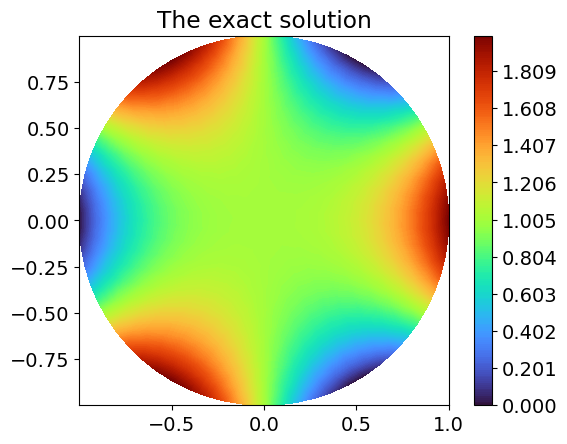

In [4]:
# Evaluate and plot the exact solution
u_exact = np.zeros((Npts,))
for j in range(Npts):
    u_exact[j] = exact_sol1(pts[j,:])

plt.figure()
plt.tricontourf(pts[:,0],pts[:,1], tri, u_exact, levels=np.linspace(0,2,200), cmap='turbo')
plt.gca().set_aspect('equal')
plt.colorbar()
plt.title("The exact solution")

In [5]:
# define the double-layer kernel for the unit circle
def dl_unit_circle(x,y):
    # y must lie on the unit circle, x can be arbitrary
    normal = y
    xy = x - y
    dxy = np.linalg.norm(xy)
    xy = xy/dxy # normalize
    return 0.5*np.dot(normal,xy)/(np.pi*dxy)


0.07957747154594767


Text(0, 0.5, '$d(0,y(\\phi))$')

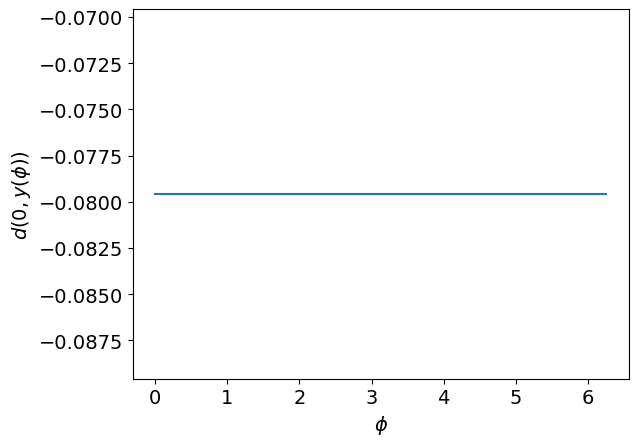

In [6]:
# Use the boundary integral equation method to solve the problem
# Use the composite trapezoidal rule to compute the integral
Nc = 200
p = np.linspace(0,2*np.pi,Nc+1)
# delete the last element, because we do not need the point 2\pi
p = np.delete(p,-1) 
h = p[1]-p[0]

Dvec = np.zeros((Nc,))
x = np.array([np.cos(p[0]),np.sin(p[0])])
for j in range(Nc):
    # print(j)
    if j != 0:
        y = np.array([np.cos(p[j]),np.sin(p[j])]) 
        Dvec[j] = dl_unit_circle(x,y)
        # print(x,y,Dvec[j])
    else:
        p1 = p[j]+0.1*h
        y1 = np.array([np.cos(p1),np.sin(p1)])
        p2 = p[j]-0.1*h 
        y2 = np.array([np.cos(p2),np.sin(p2)])
        Dvec[j] = 0.5*(dl_unit_circle(x,y1) + dl_unit_circle(x,y2))

# print(p)
# print(Dvec)
print(0.25/np.pi)
plt.figure()
plt.plot(p,Dvec)
plt.ylim([np.min(Dvec) -0.01,np.max(Dvec)+0.01])
plt.xlabel(r"$\phi$")
plt.ylabel(r"$d(0,y(\phi))$")

In [7]:
def Dmatrix(p):
    # p must be a 1D array of points on the unit circle
    N = np.size(p)
    D = np.zeros((N,N))
    for i in range(N):
        x = np.array([np.cos(p[i]),np.sin(p[i])])
        for j in range(N):        
            if i != j:
                y = np.array([np.cos(p[j]),np.sin(p[j])])            
                D[i,j] = dl_unit_circle(x,y)
            else:
                p1 = p[j]+1e-6 
                y1 = np.array([np.cos(p1),np.sin(p1)])
                p2 = p[j]-1e-6 
                y2 = np.array([np.cos(p2),np.sin(p2)])
                D[i,j] = 0.5*(dl_unit_circle(x,y1) + dl_unit_circle(x,y2))
    # h = 2*pi/N
    return 2*np.pi*D/N

D = Dmatrix(p)
A = -0.5*np.eye(Nc) + D
f = bdry_func(p)
sigma = np.linalg.solve(A, f)

In [8]:
# Evaluate the solution
u = np.zeros((Npts,))

# Interior mesh points
Ni = np.size(Interior)
Dvec = np.zeros((Nc,))
for j in range(Ni):
    ind = Interior[j]
    x = pts[ind,:]
    for k in range(Nc):
        y = np.array([np.cos(p[k]),np.sin(p[k])])
        Dvec[k] = dl_unit_circle(x,y)
    u[ind] = np.dot(Dvec,sigma)*2*np.pi/Nc
    
# Boundary points
Nb = np.size(Bdry)
for j in range(Nb):
    ind = Bdry[j]
    x = pts[Bdry[j]]
    phi = np.arctan2(x[1],x[0])
    u[ind] = bdry_func(phi)

Text(0.5, 1.0, 'The BIE solution')

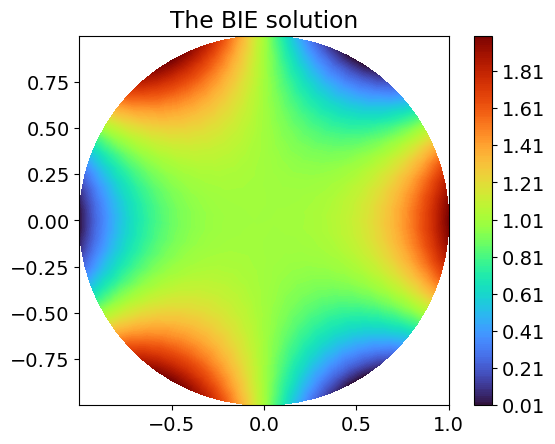

In [9]:
# visualize the computed solution
plt.figure()
plt.tricontourf(pts[:,0],pts[:,1], tri, u, levels=200, cmap='turbo')
plt.gca().set_aspect('equal')
plt.colorbar()
plt.title("The BIE solution")

RMSE = 6.5294e-07, max_err = 1.1022e-05


Text(0.5, 1.0, 'The error')

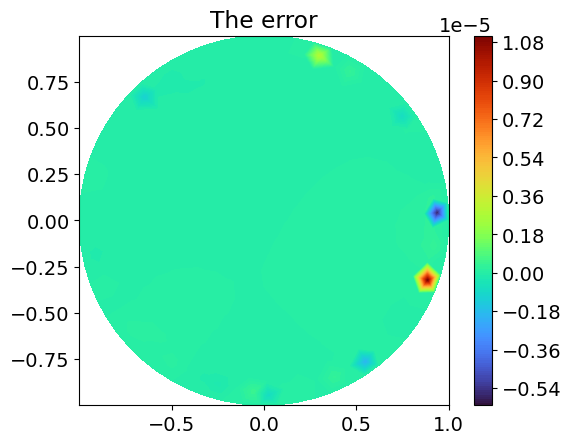

In [10]:
# visualize the error
err = u-u_exact
rmse = np.sqrt(np.sum(err**2)/Npts)
max_err = np.max(np.abs(err))
print(f"RMSE = {rmse:.4e}, max_err = {max_err:.4e}")

plt.figure()
plt.tricontourf(pts[:,0],pts[:,1], tri, err, levels=200, cmap='turbo')
plt.gca().set_aspect('equal')
plt.colorbar()
plt.title("The error")


RMSE = 5.0924e-08, max_err = 2.8134e-07


Text(0.5, 1.0, 'The error')

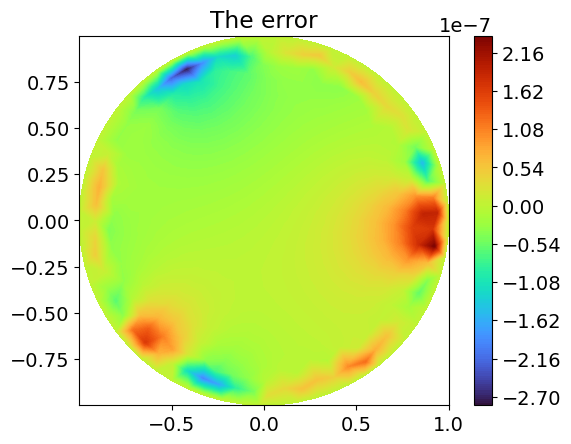

In [11]:
# Reduce error in the near field
from scipy.interpolate import CubicSpline

p_aux = np.zeros((Nc+1,))
sigma_aux = np.zeros((Nc+1,))
p_aux[:Nc] = p
p_aux[-1] = 2*np.pi
sigma_aux[:Nc] = sigma
sigma_aux[-1] = sigma[0]
cs = CubicSpline(p_aux,sigma_aux, bc_type='periodic')

p_fine = np.linspace(0, 2*np.pi, 10*Nc+1)
sigma_fine = cs(p_fine)
p_fine = np.delete(p_fine,-1)
sigma_fine = np.delete(sigma_fine,-1)
Nc_fine = np.size(p_fine)

# Interior mesh points
Ni = np.size(Interior)
Dvec_fine = np.zeros((Nc_fine,))
for j in range(Ni):
    ind = Interior[j]
    x = pts[ind,:]
    if 1 - np.linalg.norm(x) < h_mesh:
        for k in range(Nc_fine):
            y = np.array([np.cos(p_fine[k]),np.sin(p_fine[k])])
            Dvec_fine[k] = dl_unit_circle(x,y)
        u[ind] = np.dot(Dvec_fine,sigma_fine)*2*np.pi/Nc_fine

# visualize the error
err = u-u_exact
rmse = np.sqrt(np.sum(err**2)/Npts)
max_err = np.max(np.abs(err))
print(f"RMSE = {rmse:.4e}, max_err = {max_err:.4e}")

plt.figure()
plt.tricontourf(pts[:,0],pts[:,1], tri, err, levels=200, cmap='turbo')
plt.gca().set_aspect('equal')
plt.colorbar()
plt.title("The error")
